#Projet TIVO - Benammar Bilèl et Quéneudec Adrien

## Détection d'atomes

In [1]:
!pip install torch torchvision

In [32]:
# importation des bibliothèques
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import os
import glob
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset
from torchvision import transforms
import tifffile
from sklearn.metrics import confusion_matrix
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm
from random import random
# Pour utiliser dans google colab
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


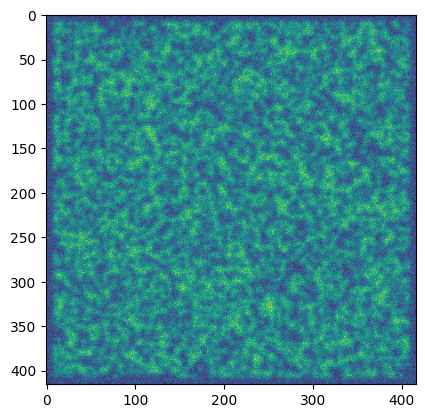

In [13]:
# Affichage de l'image
image_filename = "/content/drive/MyDrive/Colab Notebooks/dataset/data_0001.tiff"

im = np.array(Image.open(image_filename), dtype=float)/255
plt.figure()
plt.imshow(im)
plt.show()

### Classes Dataset et Unet

Puis entrainement ou utilisation du model déjà entrainé pour afficher ce que renvoie le modèle.

(Attention à bien changer le chemin dans la variable folder)

Structure détectée : TIFF à la racine


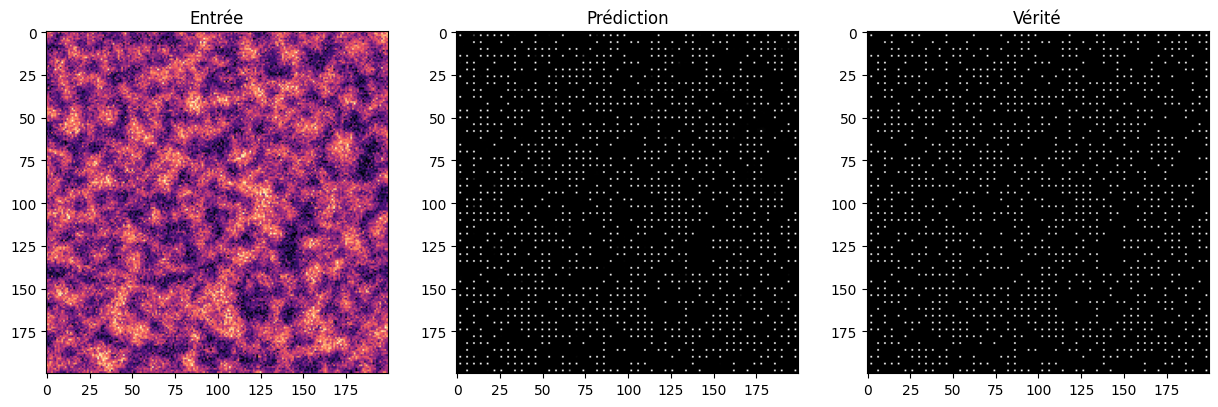

In [14]:
# Dataset
class Dataset(Dataset):
    def __init__(self, folder):
        self.folder = folder

        # Détection de la structure
        data_subfolder = os.path.join(folder, "data")
        truth_subfolder = os.path.join(folder, "occ_im")
        if os.path.isdir(data_subfolder) and os.path.isdir(truth_subfolder):
            # Dossier avec .png
            self.noisy_files = sorted(glob.glob(os.path.join(data_subfolder, "*.png")))
            self.clean_files = sorted(glob.glob(os.path.join(truth_subfolder, "*.png")))
            print(f"Structure détectée : PNG dans sous-dossiers")
        else:
            # Dossier avec .TIFF
            self.noisy_files = sorted(glob.glob(os.path.join(folder, "data_*.tiff")) +
                                      glob.glob(os.path.join(folder, "data_*.TIFF")))
            self.clean_files = sorted(glob.glob(os.path.join(folder, "truth_*.tiff")) +
                                      glob.glob(os.path.join(folder, "truth_*.TIFF")))
            print(f"Structure détectée : TIFF à la racine")

        if len(self.noisy_files) == 0:
            raise FileNotFoundError(f"Aucun fichier 'data_*.tiff' trouvé dans : {folder}")
        if len(self.noisy_files) != len(self.clean_files):
            print(f"⚠️ Attention : Déséquilibre ! {len(self.noisy_files)} data vs {len(self.clean_files)} truth")

    def __len__(self):
        return len(self.noisy_files)

    def normalize(self, img):
        img = img.astype(np.float32)
        low, high = np.percentile(img, (1, 99.9))
        img = (img - low) / (high - low + 1e-8)
        return np.clip(img, 0, 1)

    def __getitem__(self, idx):
        folder = self.folder
        data_subfolder = os.path.join(folder, "data")
        truth_subfolder = os.path.join(folder, "occ_im")

        if os.path.isdir(data_subfolder) and os.path.isdir(truth_subfolder):

            noisy = plt.imread(self.noisy_files[idx])
            clean = plt.imread(self.clean_files[idx])
            print(f"Structure détectée : PNG dans sous-dossiers")
        else:
            noisy = tifffile.imread(self.noisy_files[idx])
            clean = tifffile.imread(self.clean_files[idx])

        noisy = self.normalize(noisy)
        clean = (clean > (np.max(clean) * 0.5)).astype(np.float32)

        return torch.from_numpy(noisy).unsqueeze(0).float(), \
               torch.from_numpy(clean).unsqueeze(0).float()

# UNet
class UNet(nn.Module):
    def __init__(self):
        super().__init__()
        def cb(in_c, out_c):
            return nn.Sequential(
                nn.Conv2d(in_c, out_c, 3, padding=1),
                nn.BatchNorm2d(out_c), nn.ReLU(True),
                nn.Conv2d(out_c, out_c, 3, padding=1),
                nn.BatchNorm2d(out_c), nn.ReLU(True)
            )
        self.enc1, self.enc2 = cb(1, 32), cb(32, 64)
        self.pool = nn.MaxPool2d(2)
        self.bottleneck = cb(64, 128)
        self.up2 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.dec2 = cb(128, 64)
        self.up1 = nn.ConvTranspose2d(64, 32, 2, stride=2)
        self.dec1 = cb(64, 32)
        self.final = nn.Conv2d(32, 1, 1)

    def forward(self, x):
        s1 = self.enc1(x)
        s2 = self.enc2(self.pool(s1))
        b = self.bottleneck(self.pool(s2))

        d2 = self.up2(b)
        if d2.shape != s2.shape: d2 = torch.nn.functional.interpolate(d2, size=s2.shape[2:])
        d2 = self.dec2(torch.cat([d2, s2], dim=1))

        d1 = self.up1(d2)
        if d1.shape != s1.shape: d1 = torch.nn.functional.interpolate(d1, size=s1.shape[2:])
        d1 = self.dec1(torch.cat([d1, s1], dim=1))
        return self.final(d1)

# Entraînement
def model_train(device, model, dl, epochs=10):
    criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([300.0]).to(device))
    optimizer = optim.Adam(model.parameters(), lr=1e-4)
    loss_list = []
    for epoch in range(epochs):
        model.train()
        t_loss = 0
        for x, y in tqdm(dl, desc=f"Epoch {epoch+1}"):
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            loss = criterion(model(x), y)
            loss.backward()
            optimizer.step()
            t_loss += loss.item()
        with torch.no_grad():
          loss_list.append(model_test(model, dl))
        print(f"Loss: {t_loss/len(dl):.6f}")
    plt.figure()
    plt.plot([i for i in range(epochs)],loss_list)
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.title("Fonction de perte en fonction des epochs")
    plt.show()
    return model

def model_test(device, model, dl):
    criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([300.0]).to(device))
    model.eval()
    t_loss = 0
    for x, y in dl:
          x, y = x.to(device), y.to(device)
          loss = criterion(model(x), y)
          t_loss += loss.item()
    return t_loss

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# Nom du dossier à adapter
folder = "/content/drive/MyDrive/Colab Notebooks/dataset"

# Execution
try:
    dataset = Dataset(folder)
    # Split 80/20 pour train et test
    train_size = int(0.8 * len(dataset))
    test_size = len(dataset) - train_size
    ds_train, ds_test = torch.utils.data.random_split(dataset, [train_size, test_size])

    train_loader = DataLoader(ds_train, batch_size=4, shuffle=True)

    model = UNet().to(device)
    #model = model_train(device, model, train_loader, epochs=15)
    model = torch.load("/content/drive/MyDrive/Colab Notebooks/model.pth", map_location=device,weights_only=False)

    # Visualisation
    model.eval()
    test_loader = DataLoader(ds_test, batch_size=1)
    x, y = next(iter(test_loader))
    with torch.no_grad():
        pred = torch.sigmoid(model(x.to(device))).cpu()

    fig, ax = plt.subplots(1, 3, figsize=(15, 5))
    ax[0].imshow(x[0,0, 100:300, 100:300], cmap='magma'); ax[0].set_title("Image d'entrée")
    ax[1].imshow(pred[0,0, 100:300, 100:300], cmap='gray'); ax[1].set_title("Prédiction")
    ax[2].imshow(y[0,0, 100:300, 100:300], cmap='gray'); ax[2].set_title("Vérité")
    plt.show()

except FileNotFoundError as e:
    print(f"❌ Erreur : {e}")

Sauvegarde du modèle

In [ ]:
save_path = "/content/drive/MyDrive/Colab Notebooks"
torch.save(model, os.path.join(save_path, "model.pth"))

Calcul des matrices de confusion pour plusieurs seuils avec affichage de la courbe ROC à la fin

Calcul de la matrice de confusion sur la base de test...
Précision : 0.0289 (Capacité à ne pas avoir de faux positifs)
Rappel (Recall) : 1.0000 (Capacité à trouver tous les atomes)
Calcul de la matrice de confusion sur la base de test...
Précision : 0.9348 (Capacité à ne pas avoir de faux positifs)
Rappel (Recall) : 1.0000 (Capacité à trouver tous les atomes)
Calcul de la matrice de confusion sur la base de test...
Précision : 0.9462 (Capacité à ne pas avoir de faux positifs)
Rappel (Recall) : 1.0000 (Capacité à trouver tous les atomes)
Calcul de la matrice de confusion sur la base de test...
Précision : 0.9520 (Capacité à ne pas avoir de faux positifs)
Rappel (Recall) : 1.0000 (Capacité à trouver tous les atomes)
Calcul de la matrice de confusion sur la base de test...
Précision : 0.9559 (Capacité à ne pas avoir de faux positifs)
Rappel (Recall) : 1.0000 (Capacité à trouver tous les atomes)
Calcul de la matrice de confusion sur la base de test...
Précision : 0.9588 (Capacité à ne pas 

/tmp/ipython-input-3724603201.py:69: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure()


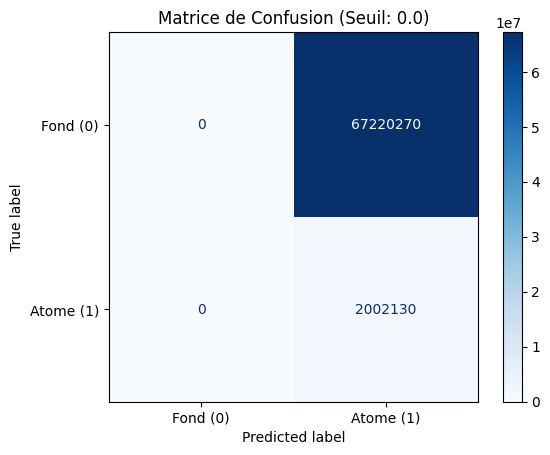

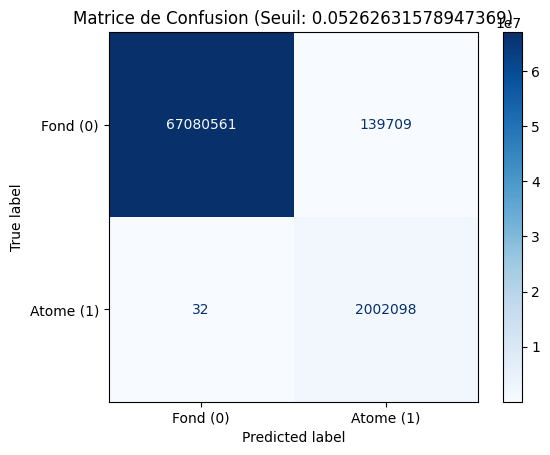

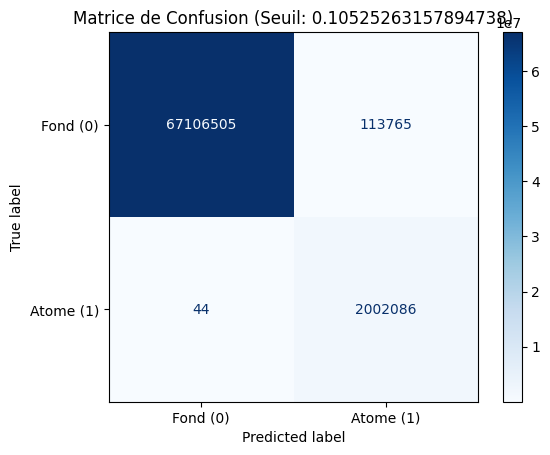

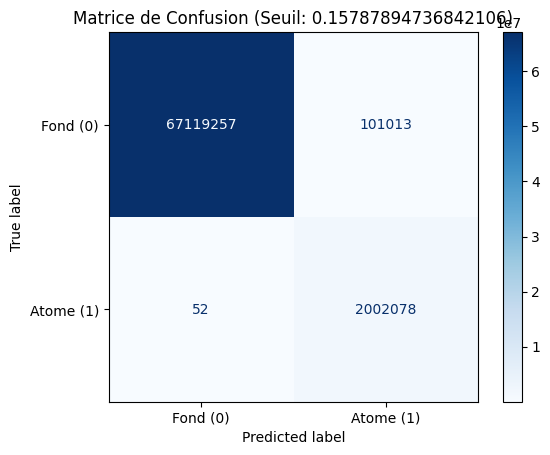

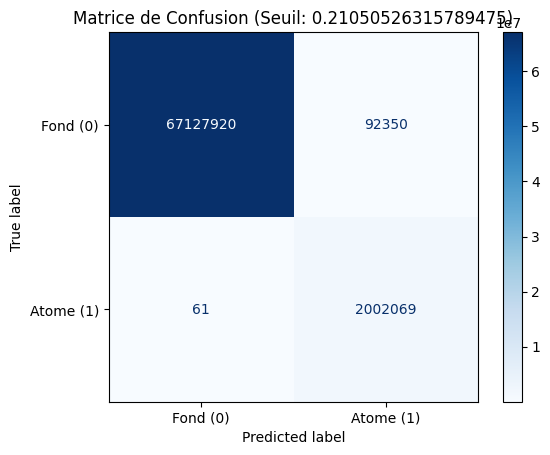

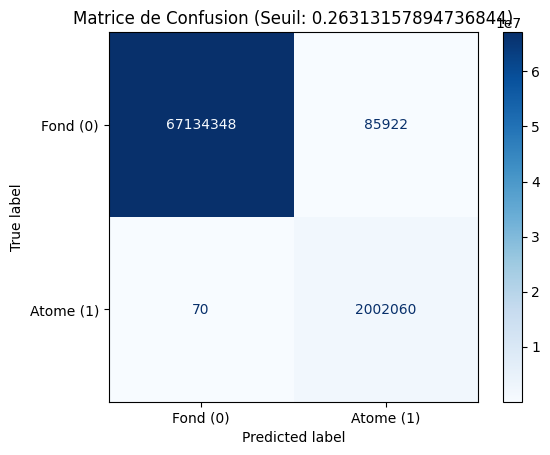

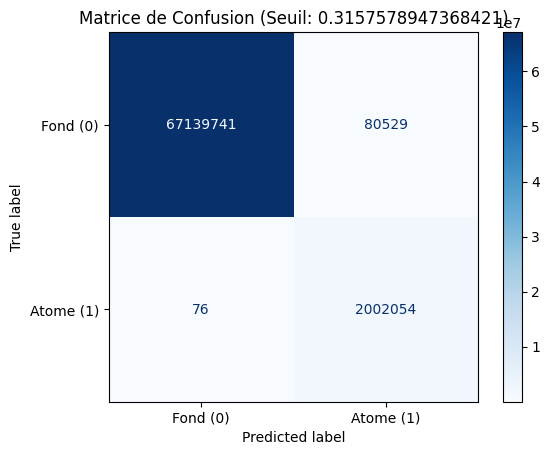

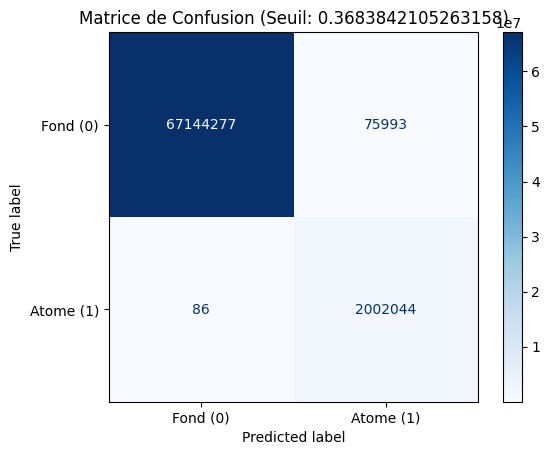

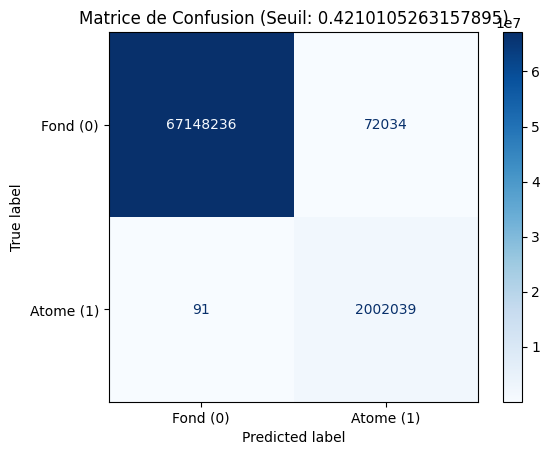

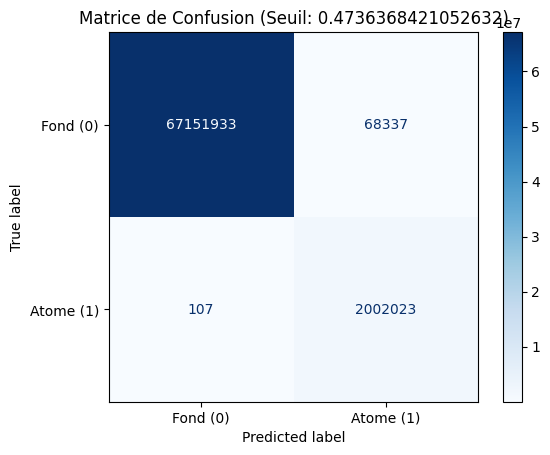

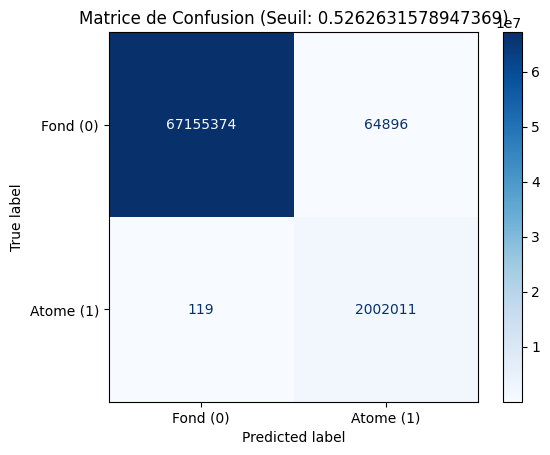

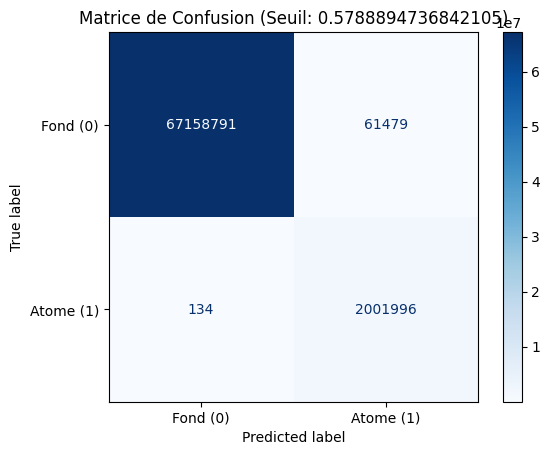

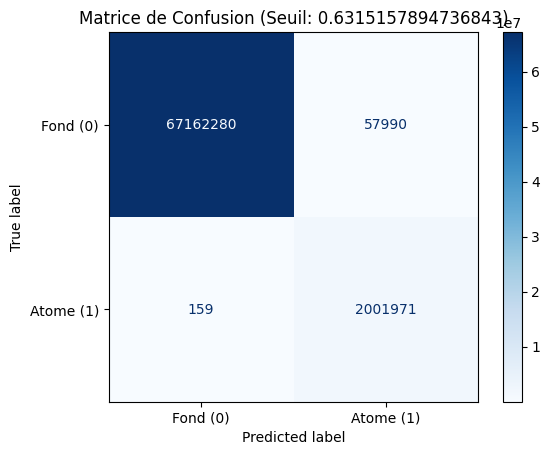

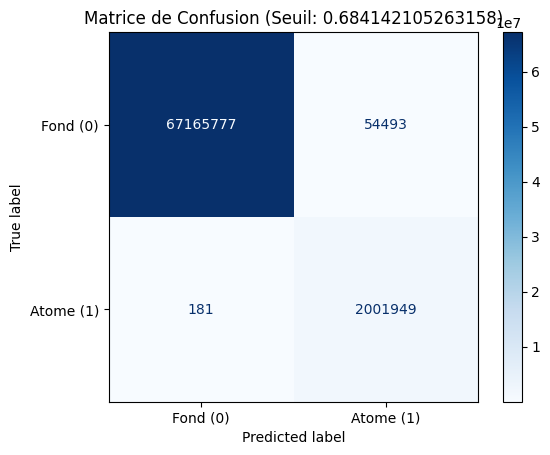

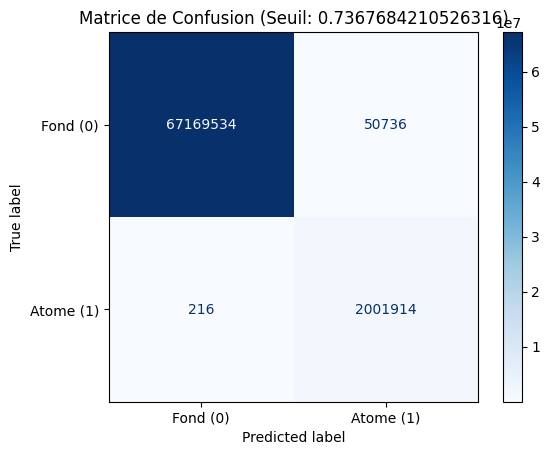

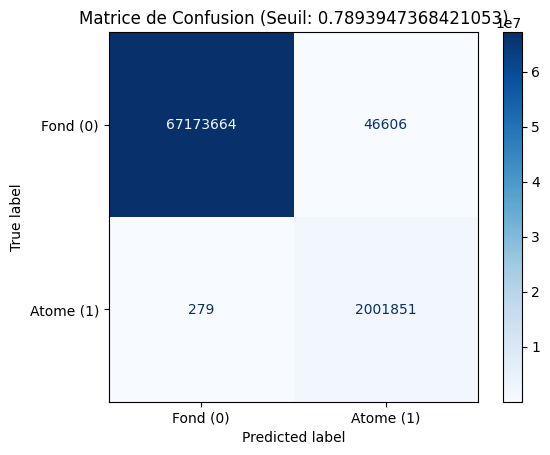

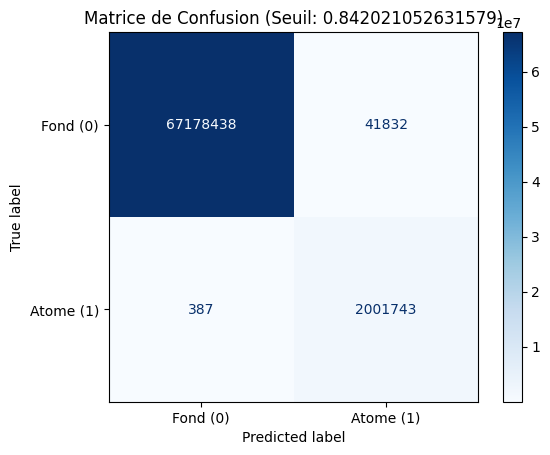

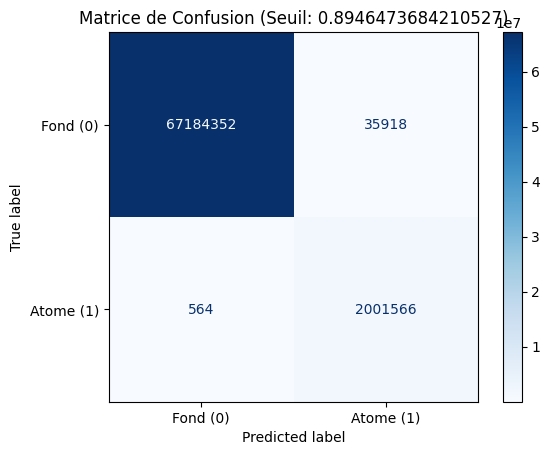

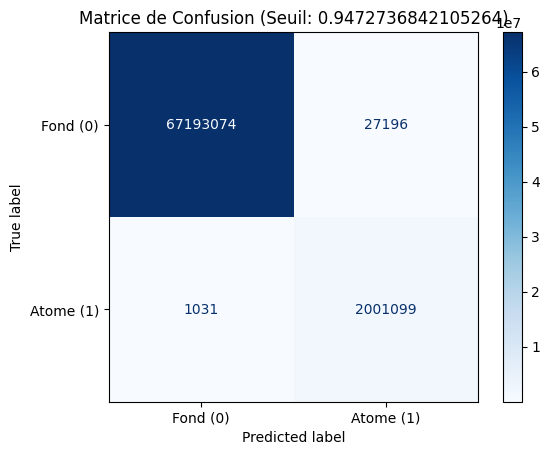

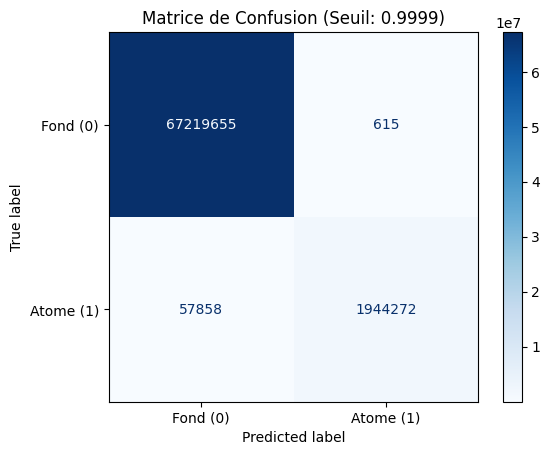

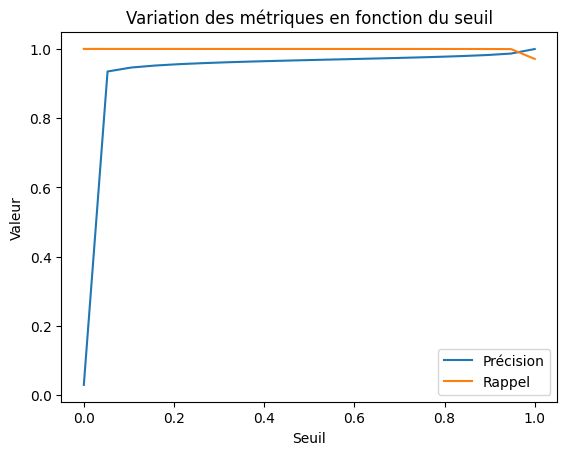

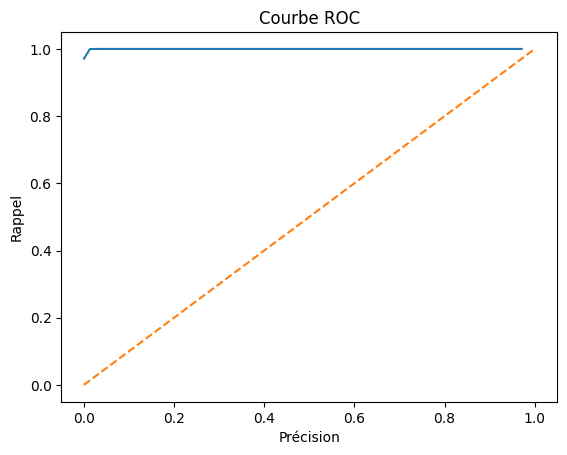

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import torch

def compute_test_confusion_matrix(model, loader, device, threshold=0.999):
    model.eval()
    all_preds = []
    all_truth = []
    print("Calcul de la matrice de confusion sur la base de test...")
    with torch.no_grad():
        for x, y in loader:

            x, y = x.to(device), y.to(device)
            if x.dim() == 3:
                x = x.unsqueeze(0)

            logits = model(x)
            probs = torch.sigmoid(logits)
            preds = (probs > threshold).float()
            all_preds.append(preds.view(-1).cpu().numpy())
            all_truth.append(y.view(-1).cpu().numpy())

    all_preds = np.concatenate(all_preds)
    all_truth = np.concatenate(all_truth)
    cm = confusion_matrix(all_truth, all_preds)

    # Affichage
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Fond (0)', 'Atome (1)'])
    disp.plot(cmap='Blues', values_format='d')
    plt.title(f'Matrice de Confusion (Seuil: {threshold})')

    # Calcul des métriques
    tn, fp, fn, tp = cm.ravel()
    precision = tp / (tp + fp + 1e-8)
    recall = tp / (tp + fn + 1e-8)
    print(f"Précision : {precision:.4f} (Capacité à ne pas avoir de faux positifs)")
    print(f"Rappel (Recall) : {recall:.4f} (Capacité à trouver tous les atomes)")
    return precision, recall



# Appel de la fonction
threshold_list = np.linspace(0,0.9999,20)
precision_list = np.array([])
recall_list = np.array([])
for threshold in threshold_list:
  precision, recall = compute_test_confusion_matrix(model, ds_test, device, threshold)
  precision_list , recall_list = np.append(precision_list, precision), np.append(recall_list, recall)


plt.figure()
plt.plot(threshold_list, precision_list, label='Précision')
plt.plot(threshold_list, recall_list, label='Rappel')
plt.title("Variation des métriques en fonction du seuil")
plt.xlabel("Seuil")
plt.ylabel("Valeur")
plt.legend()
plt.show()


plt.figure()
plt.plot(1 - precision_list, recall_list)
plt.plot([0,1], [0,1],'--')
plt.title("Courbe ROC")
plt.xlabel("Précision")
plt.ylabel("Rappel")
plt.show()



Affichage de la courbe ROC

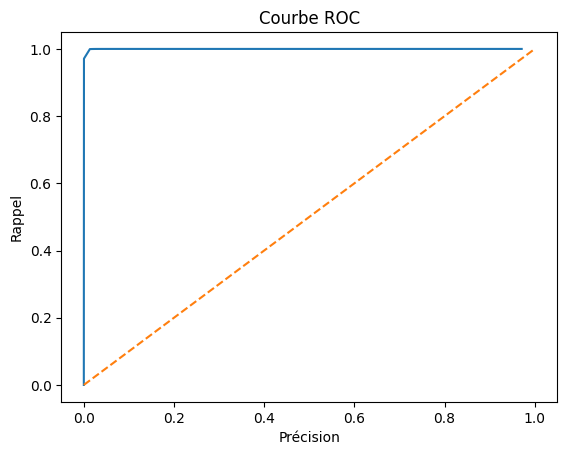

In [ ]:
plt.figure()
p_l , r_l = np.zeros(1+len(precision_list)), np.zeros(1+len(recall_list))
p_l[0:20], r_l[0:20] = 1-precision_list, recall_list
plt.plot(p_l, r_l)
plt.plot([0,1], [0,1],'--')
plt.title("Courbe ROC")
plt.xlabel("Précision")
plt.ylabel("Rappel")
plt.show()

Test du modèle entrainé sur le 1er dataset mais appliqué à un autre dataset.

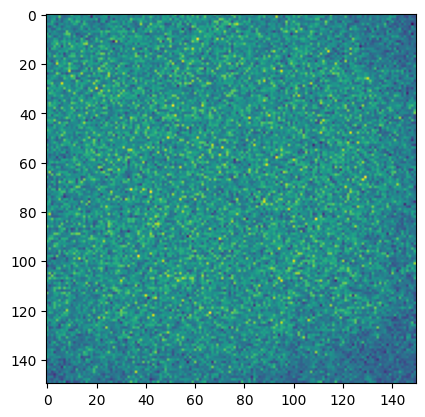

Structure détectée : PNG dans sous-dossiers
Structure détectée : PNG dans sous-dossiers


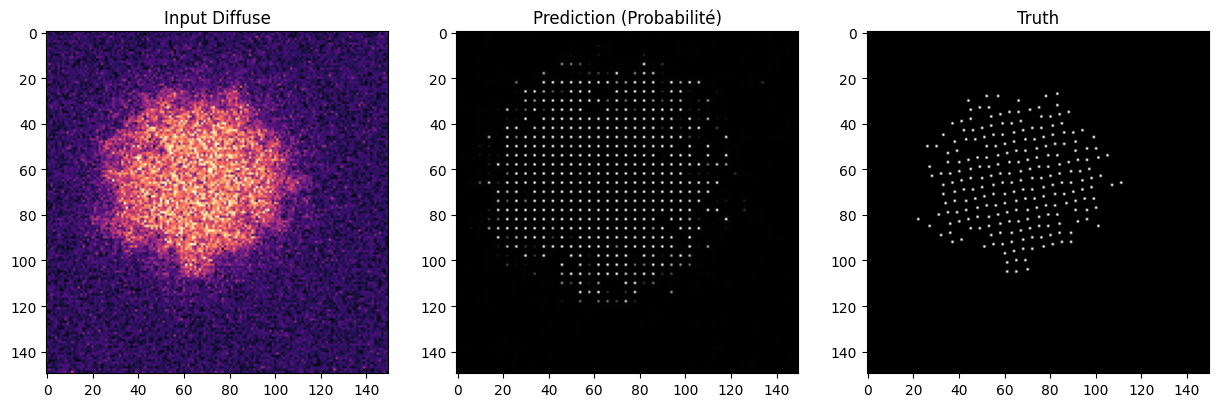

In [15]:
# Affichage d'une image de l'autre dataset
image_filename = "/content/drive/MyDrive/Colab Notebooks/database_phase_fac_0.5centerandtfixe/database_100/Train/data/im799.png"
im = np.array(Image.open(image_filename), dtype=float)/255

plt.figure()
plt.imshow(im[150:300, 150:300])
plt.show()


# Importation des dossiers d'images avec différents niveaux de bruit
folder_100 = "/content/drive/MyDrive/Colab Notebooks/database_phase_fac_0.5centerandtfixe/database_100"
folder_300 = "/content/drive/MyDrive/Colab Notebooks/database_phase_fac_0.5centerandtfixe/database_300"
folder_500 = "/content/drive/MyDrive/Colab Notebooks/database_phase_fac_0.5centerandtfixe/database_500"
folder_700 = "/content/drive/MyDrive/Colab Notebooks/database_phase_fac_0.5centerandtfixe/database_700"

# Exectution du modèle à l'autre database
try:
    model = UNet().to(device)
    model = torch.load("/content/drive/MyDrive/Colab Notebooks/model.pth", map_location=device,weights_only=False)

    # Visualisation
    model.eval()
    ds_test = Dataset(folder_300)
    test_loader = DataLoader(ds_test, batch_size=1)
    x, y = next(iter(test_loader))
    with torch.no_grad():
        pred = torch.sigmoid(model(x.to(device))).cpu()

    fig, ax = plt.subplots(1, 3, figsize=(15, 5))
    ax[0].imshow(x[0,0, 150:300, 150:300], cmap='magma'); ax[0].set_title("Image d'entrée")
    ax[1].imshow(pred[0,0, 150:300, 150:300], cmap='gray'); ax[1].set_title("Prédiction")
    ax[2].imshow(y[0,0, 150:300, 150:300], cmap='gray'); ax[2].set_title("Vérité")
    plt.show()

except FileNotFoundError as e:
    print(f"❌ Erreur : {e}")

On observe bien que le modèle entrainé avec le 1er dataset n'arrive pas à bien faire la détection d'atomes sur le nouveau dataset.

On suppose que c'est dû à la rotation qui a lieu sur l'autre dataset.
On va donc essayer de la prendre en compte par la suite.

In [50]:
# Nouvelle classe de dataset qui prend en compte la rotation
import torchvision.transforms.functional as TF

class Dataset_rotation(Dataset):
    def __init__(self, folder, augment=False):
        self.folder = folder
        self.augment = augment

        data_sub = os.path.join(folder, "data")
        truth_sub = os.path.join(folder, "occ_im")

        if os.path.isdir(data_sub) and os.path.isdir(truth_sub):
            self.noisy_files = sorted(glob.glob(os.path.join(data_sub, "*.png")))
            self.clean_files = sorted(glob.glob(os.path.join(truth_sub, "*.png")))
            self.mode = "png"
        else:
            self.noisy_files = sorted(glob.glob(os.path.join(folder, "data_*.tiff")) +
                                     glob.glob(os.path.join(folder, "data_*.TIFF")))
            self.clean_files = sorted(glob.glob(os.path.join(folder, "truth_*.tiff")) +
                                     glob.glob(os.path.join(folder, "truth_*.TIFF")))
            self.mode = "tiff"

        if len(self.noisy_files) == 0:
            raise FileNotFoundError(f"Aucun fichier trouvé dans : {folder}")

    def __len__(self):
        return len(self.noisy_files)

    def normalize(self, img):
        img = img.astype(np.float32)
        low, high = np.percentile(img, (1, 99.9))
        return np.clip((img - low) / (high - low + 1e-8), 0, 1)

    def __getitem__(self, idx):
        if self.mode == "png":
            noisy = plt.imread(self.noisy_files[idx])
            clean = plt.imread(self.clean_files[idx])
        else:
            noisy = tifffile.imread(self.noisy_files[idx])
            clean = tifffile.imread(self.clean_files[idx])

        noisy = self.normalize(noisy)
        clean = (clean > (np.max(clean) * 0.5)).astype(np.float32)

        x = torch.from_numpy(noisy).unsqueeze(0).float()
        y = torch.from_numpy(clean).unsqueeze(0).float()

        if self.augment:
            # Rotation aléatoire
            angle = np.random.uniform(-180, 180)
            x = TF.rotate(x, angle, interpolation=TF.InterpolationMode.BILINEAR)
            y = TF.rotate(y, angle, interpolation=TF.InterpolationMode.NEAREST)

        return x, y

In [53]:
FOLDER_PATH = "/content/drive/MyDrive/Colab Notebooks/dataset"
# Préparation du Dataset
try:
    full_dataset = Dataset_rotation(FOLDER_PATH)

    #Split 80% Train et 20% Test
    train_size = int(0.8 * len(dataset))
    test_size = len(dataset) - train_size
    ds_train, ds_test = torch.utils.data.random_split(Dataset_rotation(FOLDER_PATH, augment=True), [train_size, test_size])


    # Création des DataLoaders
    train_loader = DataLoader(ds_train, batch_size=4, shuffle=True)
    test_loader = DataLoader(ds_test, batch_size=1, shuffle=False)

except FileNotFoundError as e:
    print(f"ERREUR : {e}")

In [ ]:
# Initialisation et Entraînement
model = UNet().to(device)
MODEL_SAVE_PATH = "/content/drive/MyDrive/Colab Notebooks/model_rotation.pth"
LOAD_MODEL = False # Mettre à True pour charger un modèle existant

if not LOAD_MODEL:
    print("🚀 Démarrage de l'entraînement (ceci peut être plus long avec les rotations)...")
    model = model_train(device, model, train_loader, epochs=10)

    # Sauvegarde des poids
    #torch.save(model.state_dict(), MODEL_SAVE_PATH)

else:
    model.load_state_dict(torch.load(MODEL_SAVE_PATH, map_location=device))
    model.eval()

🚀 Démarrage de l'entraînement (ceci peut être plus long avec les rotations)...


Epoch 1:   5%|▍         | 19/400 [00:04<01:22,  4.62it/s]

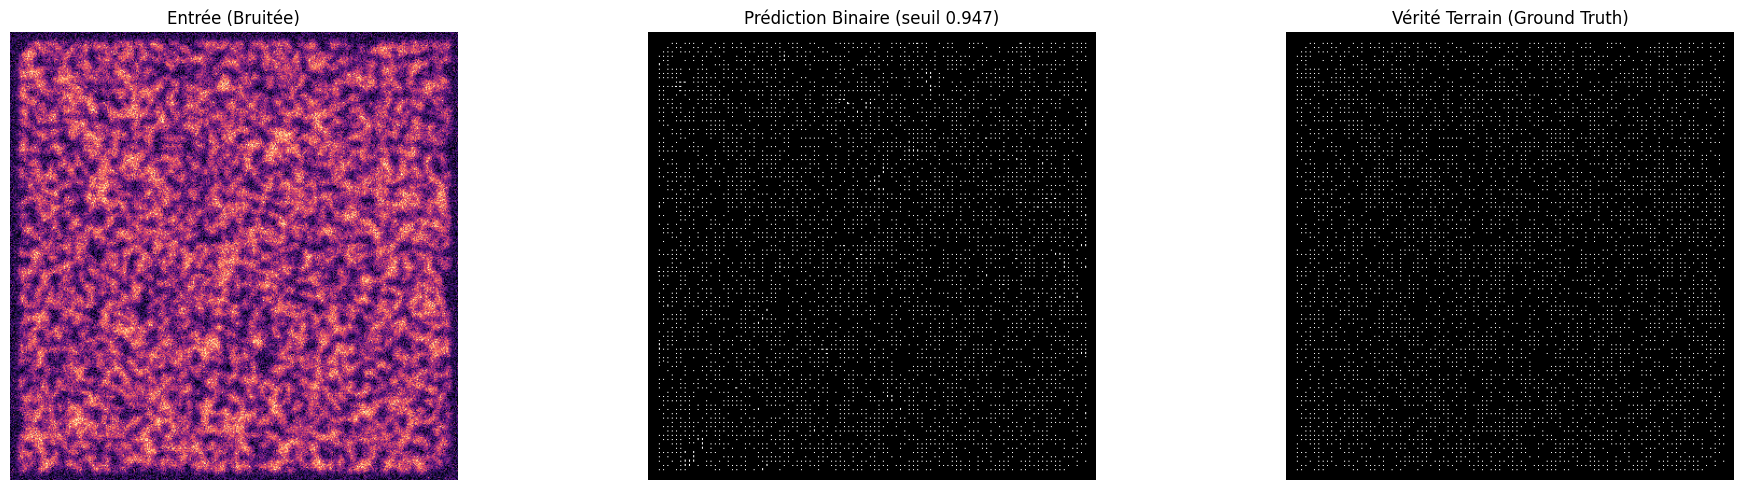

In [31]:
# Évaluation du modèle avec rotation avec un seuil de 0.947
model.eval()
x, y = next(iter(test_loader))
threshold = 0.947

with torch.no_grad():
    logits = model(x.to(device))
    probs = torch.sigmoid(logits).cpu()
    pred_bin = (probs > threshold).float()

# Affichage des résultats
fig, ax = plt.subplots(1, 3, figsize=(20, 5))

# Image d'entrée
ax[0].imshow(x[0,0], cmap='magma')
ax[0].set_title("Entrée (Bruitée)")

# Prédiction Binaire
ax[1].imshow(pred_bin[0,0], cmap='gray')
ax[1].set_title(f"Prédiction Binaire (seuil {threshold})")

# Vérité
ax[2].imshow(y[0,0], cmap='gray')
ax[2].set_title("Vérité Terrain (Ground Truth)")

for a in ax: a.axis('off')
plt.tight_layout()
plt.show()

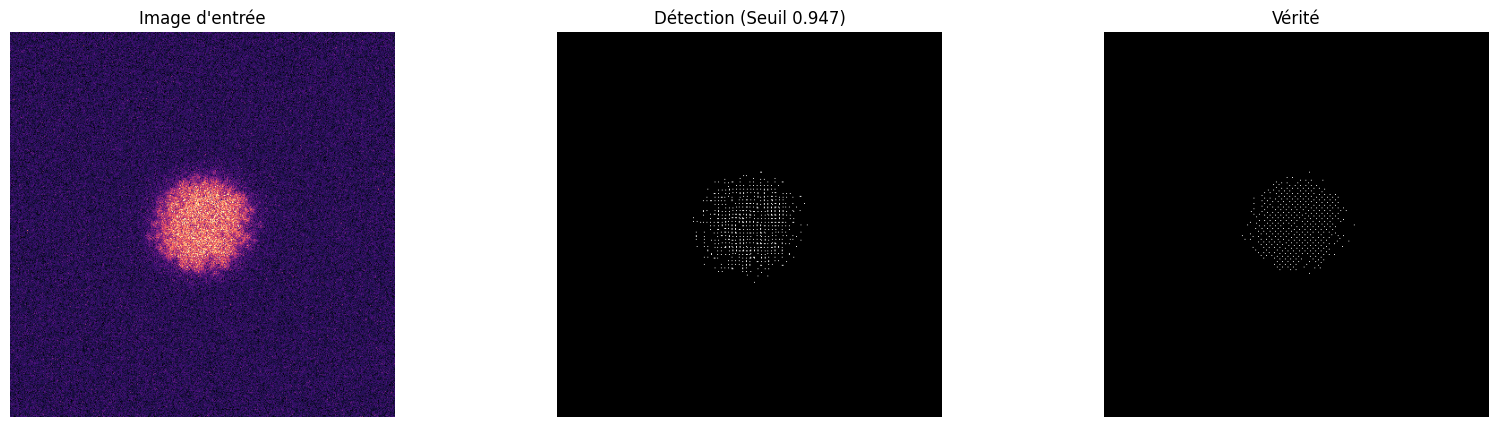

In [30]:
from PIL import Image

# 1. Configuration des chemins de test
image_individuelle = "/content/drive/MyDrive/Colab Notebooks/database_phase_fac_0.5centerandtfixe/database_100/Train/data/im799.png"
folders = {
    "Niveau 100": "/content/drive/MyDrive/Colab Notebooks/database_phase_fac_0.5centerandtfixe/database_100",
    "Niveau 300": "/content/drive/MyDrive/Colab Notebooks/database_phase_fac_0.5centerandtfixe/database_300",
    "Niveau 500": "/content/drive/MyDrive/Colab Notebooks/database_phase_fac_0.5centerandtfixe/database_500",
    "Niveau 700": "/content/drive/MyDrive/Colab Notebooks/database_phase_fac_0.5centerandtfixe/database_700"
}

# 2. Paramètre de seuil pour la sortie binaire
threshold_test = 0.947
model.eval()
nom_dossier = "Niveau 100"

try:
    ds_specifique = Dataset_rotation(folders[nom_dossier], augment=False)
    loader_specifique = DataLoader(ds_specifique, batch_size=1, shuffle=True)
    x, y = next(iter(loader_specifique))

    with torch.no_grad():
        probs = torch.sigmoid(model(x.to(device))).cpu()
        pred_bin = (probs > threshold_test).float()

    fig, ax = plt.subplots(1, 3, figsize=(20, 5))
    ax[0].imshow(x[0,0], cmap='magma'); ax[0].set_title(f"Image d'entrée")
    ax[1].imshow(pred_bin[0,0], cmap='gray'); ax[1].set_title(f"Détection (Seuil {threshold_test})")
    ax[2].imshow(y[0,0], cmap='gray'); ax[2].set_title("Vérité")

    for a in ax: a.axis('off')
    plt.show()

except Exception as e:
    print(f"Erreur dossier {nom_dossier} : {e}")